
# P_04 LSTM




## Opis wybranej spółki i danych



Do przeprowadzenia eksperymentów wybrano spółkę NVIDIA notowaną na giełdzie NASDAQ pod symbolem NVDA. Przedsiębiorstwo działa w branży półprzewodników i jest jednym z kluczowych producentów procesorów graficznych oraz rozwiązań obliczeniowych dla centrów danych i zastosowań AI.


## Instalacja i import bibliotek



In [ ]:
import os, random
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from sklearn.preprocessing import MinMaxScaler
from sklearn.metrics import mean_absolute_error
import yfinance as yf
import tensorflow as tf
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import LSTM, Dense
from tensorflow.keras.callbacks import EarlyStopping
from tensorflow.keras import optimizers
import time


#Dane

Dane pozyskane przy użyciu biblioteki yfinance, w postaci dziennych notowań dla okresu 2020-01-01 – 2026-01-01.

Zgodnie z założeniami projektu  do modelowania wykorzystano wyłącznie kolumnę Close.


## Pobieranie danych giełdowych


In [ ]:
ticker = 'NVDA'
start_date = '2020-01-01'
end_date = '2026-01-01'

data = yf.download(ticker, start=start_date, end=end_date)
display(data.head())
print(f'Liczba dni w zbiorze: {len(data)}')

prices = data[['Close']].dropna()


/tmp/ipython-input-2447033263.py:5: FutureWarning: YF.download() has changed argument auto_adjust default to True
  data = yf.download(ticker, start=start_date, end=end_date)
[*********************100%***********************]  1 of 1 completed


Price,Close,High,Low,Open,Volume
Ticker,NVDA,NVDA,NVDA,NVDA,NVDA
Date,,,,,
2020-01-02,5.971077,5.971077,5.891682,5.942206,237536000
2020-01-03,5.875504,5.919308,5.826473,5.851362,205384000
2020-01-06,5.900144,5.905371,5.756038,5.782171,262636000
2020-01-07,5.971576,6.017371,5.883469,5.928518,314856000
2020-01-08,5.982774,6.024089,5.927272,5.967343,277108000


Liczba dni w zbiorze: 1508


##Wizualizacja historycznych cen zamknięcia

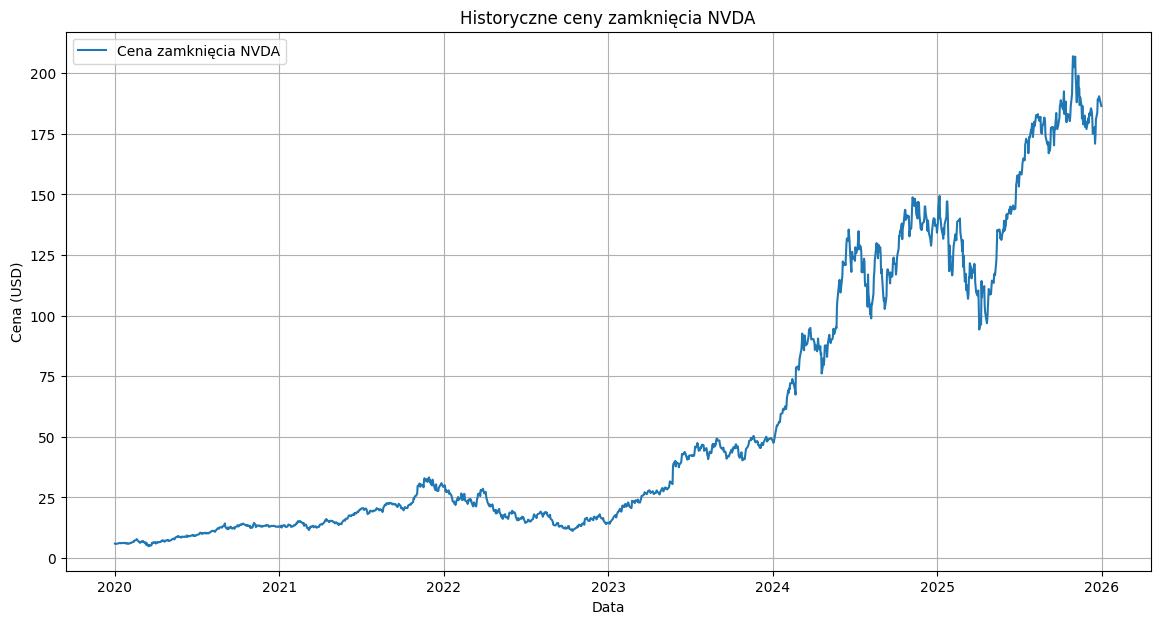

In [ ]:

plt.figure(figsize=(14, 7))
plt.plot(prices.index, prices['Close'], label='Cena zamknięcia NVDA')
plt.title('Historyczne ceny zamknięcia NVDA')
plt.xlabel('Data')
plt.ylabel('Cena (USD)')
plt.legend()
plt.grid(True)
plt.show()

Wykres przedstawia przebieg historycznych cen zamknięcia akcji NVDA w latach 2020–2026. Widoczny jest długookresowy trend wzrostowy, przy czym dynamika zmian wyraźnie nasila się w końcowej części szeregu, gdzie obserwowane są również większe wahania krótkoterminowe. Oznacza to, że seria łączy okresy relatywnej stabilności z fazami podwyższonej zmienności, co może utrudniać precyzyjną predykcję w momentach gwałtownych zmian.

##Wizualizacja dziennych zwrotów

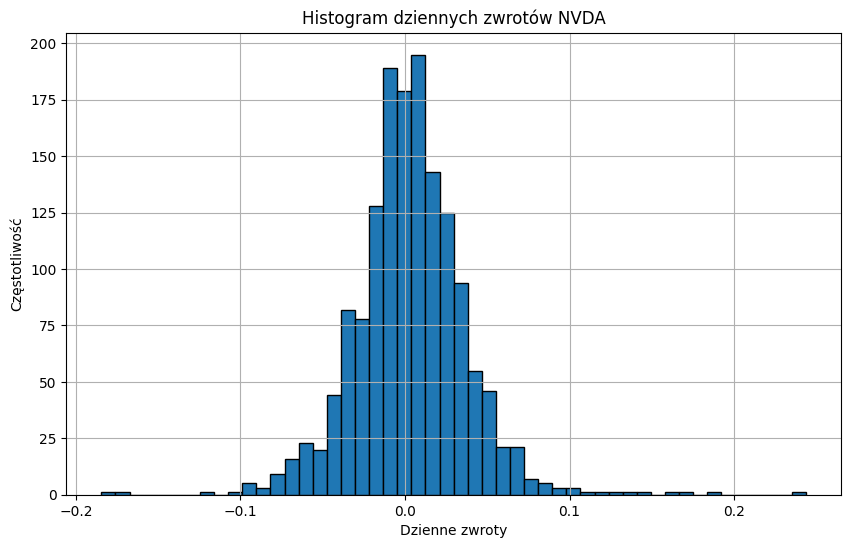

In [ ]:

daily_returns = prices['Close'].pct_change().dropna()
plt.figure(figsize=(10, 6))
plt.hist(daily_returns, bins=50, edgecolor='black')
plt.title('Histogram dziennych zwrotów NVDA')
plt.xlabel('Dzienne zwroty')
plt.ylabel('Częstotliwość')
plt.grid(True)
plt.show()

Histogram prezentuje rozkład dziennych zwrotów akcji NVDA, skoncentrowany w pobliżu zera, co wskazuje, że większość dziennych zmian ma niewielką wartość bezwzględną. Jednocześnie zauważalne są obserwacje skrajne po obu stronach rozkładu, co sugeruje występowanie dni o ponadprzeciętnych wzrostach lub spadkach. Tego typu rzadkie, lecz silne wahania stanowią typowe źródło większych błędów predykcji w modelach opartych wyłącznie na danych historycznych.


## Przygotowanie danych: normalizacja i tworzenie sekwencji

Zmienna czasowa została przeskalowana do zakresu [0, 1] z wykorzystaniem MinMaxScaler. Następnie skonstruowano sekwencje o długości n_steps, przy czym każdej sekwencji przypisano etykietę odpowiadającą wartości bezpośrednio następującej po oknie.

Dane podzielono w sposób chronologiczny, na trzy rozłączne podzbiory: treningowy (70%), walidacyjny (20%) oraz testowy (10%).


In [ ]:

# ustawienie długości okna czasowego
n_steps = 30

# skalowanie danych
scaler = MinMaxScaler(feature_range=(0, 1))
scaled = scaler.fit_transform(prices)


# funkcja generująca sekwencje
def create_sequences(series, n_steps):
    X, y = [], []
    for i in range(n_steps, len(series)):
        X.append(series[i - n_steps:i])
        y.append(series[i])
    return np.array(X), np.array(y)

# tworzenie sekwencji
X_all, y_all = create_sequences(scaled, n_steps)

# podział na zbiory
train_size = int(len(X_all) * 0.7)
val_size = int(len(X_all) * 0.2)

X_train, y_train = X_all[:train_size], y_all[:train_size]
X_val, y_val = X_all[train_size:train_size + val_size], y_all[train_size:train_size + val_size]
X_test, y_test = X_all[train_size + val_size:], y_all[train_size + val_size:]

# dostosowanie kształtu do wejścia LSTM
X_train = X_train.reshape((X_train.shape[0], X_train.shape[1], 1))
X_val = X_val.reshape((X_val.shape[0], X_val.shape[1], 1))
X_test = X_test.reshape((X_test.shape[0], X_test.shape[1], 1))

y_test_inv = scaler.inverse_transform(y_test).flatten()



## Funkcja budująca modele LSTM

Poniższa funkcja została stworzona w celu uproszczenia kodu i za argumenty przyjmuje parametry modeli.


In [ ]:

def build_lstm_model(n_layers=1, units=50, dropout=0.0, optimizer_name='adam', learning_rate=0.001):
    tf.keras.utils.set_random_seed(seed=42)
    np.random.seed(seed=42)
    random.seed(42)
    try:
      tf.config.experimental.enable_op_determinism()
    except Exception:
      pass
    model = Sequential()
    for i in range(n_layers):
        return_seq = True if i < n_layers - 1 else False
        # dodanie warstw LSTM
        model.add(LSTM(units=units, return_sequences=return_seq, dropout=dropout, input_shape=(None, 1)))
    model.add(Dense(1))
    # konfiguracja optymalizatora
    if optimizer_name == 'adam':
        opt = optimizers.Adam(learning_rate=learning_rate)
    elif optimizer_name == 'rmsprop':
        opt = optimizers.RMSprop(learning_rate=learning_rate)
    else:
        opt = optimizer_name
    model.compile(optimizer=opt, loss='mse', metrics=['mae'])
    return model



## Model bazowy
* Warstwa Input z kształtem (n_steps, 1)
* Jedna warstwa LSTM z 50 jednostkami
* Warstwa Dense z 1 neuronem (regresja)



In [ ]:
model = build_lstm_model(n_layers=1, units=50, dropout=0.0, optimizer_name='adam', learning_rate=0.001)
start_time = time.time()
model.fit(X_train, y_train, epochs=30, batch_size=32, validation_data=(X_val, y_val), verbose=0,
              callbacks=[EarlyStopping(monitor='val_loss', patience=5, restore_best_weights=True)])
training_time = time.time() - start_time
test_pred = model.predict(X_test).flatten()
test_pred_inv = scaler.inverse_transform(test_pred.reshape(-1, 1)).flatten()
mae = mean_absolute_error(y_test_inv, test_pred_inv)
baseline = [{'konfiguracja': 'baseline', 'mae': mae, 'czas_treningu': training_time}]
print(f"mae: {mae}, czas_treningu: {training_time}")

/usr/local/lib/python3.12/dist-packages/keras/src/layers/rnn/rnn.py:199: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(**kwargs)


5/5 ━━━━━━━━━━━━━━━━━━━━ 0s 30ms/step
mae: 9.805253304091076, czas_treningu: 13.713149070739746


Model 1 uzyskał MAE 9.80 przy czasie treningu 13.71 s, co stanowi punkt odniesienia do dalszych konfiguracji

##Model naiwny

In [ ]:
naive_predictions = []
for seq in X_test:
    naive_predictions.append(seq[-1, 0])
naive_predictions = np.array(naive_predictions)

naive_pred_inv = scaler.inverse_transform(naive_predictions.reshape(-1, 1)).flatten()
y_test_inv = scaler.inverse_transform(y_test).flatten()

naive_mae = mean_absolute_error(y_test_inv, naive_pred_inv)

naive = [{'konfiguracja': 'naiwny', 'mae': naive_mae, 'czas_treningu': 0.0}]
print(f'Model naiwny – MAE: {naive_mae:.4f}')

Model naiwny – MAE: 2.7971


Model naiwny, oparty na założeniu „następna wartość = ostatnia obserwacja z okna”, osiągnął MAE = 2.80, wyraźnie przewyższył model bazowy LSTM. Oznacza to, że w tym zbiorze danych cena z kolejnego dnia często jest bardzo zbliżona do ceny z dnia poprzedniego, przez co proste podejście jest trudne do pobicia bez dodatkowych zmiennych wejściowych.


## Eksperyment 1: wpływ liczby warstw LSTM

* Model z 1 warstwą LSTM
* Model z 2 warstwami LSTM
* Model z 3 warstwami LSTM

In [ ]:

results_depth = []
for layers in [1, 2, 3]:
    model = build_lstm_model(n_layers=layers, units=50, dropout=0.0, optimizer_name='adam', learning_rate=0.001)
    start_time = time.time()
    model.fit(X_train, y_train, epochs=30, batch_size=32, validation_data=(X_val, y_val), verbose=0,
              callbacks=[EarlyStopping(monitor='val_loss', patience=5, restore_best_weights=True)])
    training_time = time.time() - start_time

    test_pred = model.predict(X_test).flatten()
    test_pred_inv = scaler.inverse_transform(test_pred.reshape(-1, 1)).flatten()
    mae = mean_absolute_error(y_test_inv, test_pred_inv)
    results_depth.append({'konfiguracja': f'{layers} warstw', 'mae': mae, 'czas_treningu': training_time})


for res in results_depth:
    print(res)


/usr/local/lib/python3.12/dist-packages/keras/src/layers/rnn/rnn.py:199: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(**kwargs)


5/5 ━━━━━━━━━━━━━━━━━━━━ 0s 31ms/step


/usr/local/lib/python3.12/dist-packages/keras/src/layers/rnn/rnn.py:199: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(**kwargs)


5/5 ━━━━━━━━━━━━━━━━━━━━ 1s 77ms/step


/usr/local/lib/python3.12/dist-packages/keras/src/layers/rnn/rnn.py:199: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(**kwargs)


5/5 ━━━━━━━━━━━━━━━━━━━━ 1s 105ms/step
{'konfiguracja': '1 warstw', 'mae': 9.805253304091076, 'czas_treningu': 13.908508777618408}
{'konfiguracja': '2 warstw', 'mae': 8.05581071072777, 'czas_treningu': 22.421380043029785}
{'konfiguracja': '3 warstw', 'mae': 18.282247044096056, 'czas_treningu': 11.01263952255249}


W eksperymencie dotyczącym wpływu głębokości sieci najkorzystniejszy rezultat uzyskał model dwuwarstwowy (MAE = 8.06) przy wydłużonym czasie treningu (22.42 s) względem wariantu jednowarstwowego (MAE = 9.81; 13.91 s). Zwiększenie liczby warstw do trzech istotnie pogorszyło jakość predykcji (MAE = 18.28), co może wskazywać na trudności w uczeniu bardziej złożonej architektury w analizowanych warunkach.


## Eksperyment 2: liczba jednostek w warstwach LSTM

Drugi eksperyment bada wpływ liczby jednostek w dwuwarstwowej sieci LSTM. Testowane są wartości 32, 50, 64 i 128 jednostek.


In [ ]:

results_units = []
for units in [32, 50, 64, 128]:
    model = build_lstm_model(n_layers=2, units=units, dropout=0.0, optimizer_name='adam', learning_rate=0.001)
    start_time = time.time()
    model.fit(X_train, y_train, epochs=30, batch_size=32, validation_data=(X_val, y_val), verbose=0,
              callbacks=[EarlyStopping(monitor='val_loss', patience=5, restore_best_weights=True)])
    training_time = time.time() - start_time
    test_pred = model.predict(X_test).flatten()
    test_pred_inv = scaler.inverse_transform(test_pred.reshape(-1, 1)).flatten()
    mae = mean_absolute_error(y_test_inv, test_pred_inv)
    results_units.append({'konfiguracja': f'{units} jednostek', 'mae': mae, 'czas_treningu': training_time})

for res in results_units:
    print(res)


/usr/local/lib/python3.12/dist-packages/keras/src/layers/rnn/rnn.py:199: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(**kwargs)


5/5 ━━━━━━━━━━━━━━━━━━━━ 0s 52ms/step


/usr/local/lib/python3.12/dist-packages/keras/src/layers/rnn/rnn.py:199: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(**kwargs)


5/5 ━━━━━━━━━━━━━━━━━━━━ 0s 56ms/step


/usr/local/lib/python3.12/dist-packages/keras/src/layers/rnn/rnn.py:199: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(**kwargs)


5/5 ━━━━━━━━━━━━━━━━━━━━ 0s 54ms/step


/usr/local/lib/python3.12/dist-packages/keras/src/layers/rnn/rnn.py:199: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(**kwargs)


5/5 ━━━━━━━━━━━━━━━━━━━━ 0s 61ms/step
{'konfiguracja': '32 jednostek', 'mae': 4.602804401576919, 'czas_treningu': 19.507732391357422}
{'konfiguracja': '50 jednostek', 'mae': 8.05581071072777, 'czas_treningu': 22.791883945465088}
{'konfiguracja': '64 jednostek', 'mae': 11.313608259162647, 'czas_treningu': 27.13360023498535}
{'konfiguracja': '128 jednostek', 'mae': 6.107814302380453, 'czas_treningu': 14.74980616569519}


W eksperymencie analizującym wpływ liczby jednostek w architekturze dwuwarstwowej najniższy błąd uzyskał wariant z 32 jednostkami (MAE = 4.60; 19.51 s), co wskazuje na wystarczającą pojemność modelu przy relatywnie umiarkowanym koszcie obliczeniowym. Zwiększanie liczby jednostek do 50 i 64 prowadziło do systematycznego pogorszenia jakości predykcji (odpowiednio MAE = 8.06 i 11.31), natomiast konfiguracja 128 jednostek poprawiła wynik względem 50/64 (MAE = 6.11), osiągając jednocześnie najkrótszy czas treningu (14.75 s).


## Eksperyment 3: długość okna czasowego (lookback)

 Dla każdej z wartości 7, 14, 30, 60 oraz 90 dni budowane są sekwencje danych od nowa, a następnie trenowany jest model dwuwarstwowy z 50 jednostkami.


In [ ]:

results_lookback = []
for steps in [7, 14, 30, 60, 90]:
    # ponowne przygotowanie danych z nowym oknem
    X_all_lb, y_all_lb = create_sequences(scaled, steps)
    train_size_lb = int(len(X_all_lb) * 0.7)
    val_size_lb = int(len(X_all_lb) * 0.2)
    X_train_lb, y_train_lb = X_all_lb[:train_size_lb], y_all_lb[:train_size_lb]
    X_val_lb, y_val_lb = X_all_lb[train_size_lb:train_size_lb + val_size_lb], y_all_lb[train_size_lb:train_size_lb + val_size_lb]
    X_test_lb, y_test_lb = X_all_lb[train_size_lb + val_size_lb:], y_all_lb[train_size_lb + val_size_lb:]
    X_train_lb = X_train_lb.reshape((X_train_lb.shape[0], X_train_lb.shape[1], 1))
    X_val_lb = X_val_lb.reshape((X_val_lb.shape[0], X_val_lb.shape[1], 1))
    X_test_lb = X_test_lb.reshape((X_test_lb.shape[0], X_test_lb.shape[1], 1))
    # budowa i trening modelu
    model = build_lstm_model(n_layers=2, units=50, dropout=0.0, optimizer_name='adam', learning_rate=0.001)
    start_time = time.time()
    model.fit(X_train_lb, y_train_lb, epochs=30, batch_size=32, validation_data=(X_val_lb, y_val_lb), verbose=0,
              callbacks=[EarlyStopping(monitor='val_loss', patience=5, restore_best_weights=True)])
    training_time = time.time() - start_time
    test_pred = model.predict(X_test_lb).flatten()
    test_pred_inv = scaler.inverse_transform(test_pred.reshape(-1, 1)).flatten()
    y_test_inv_lb = scaler.inverse_transform(y_test_lb).flatten()
    mae = mean_absolute_error(y_test_inv_lb, test_pred_inv)
    results_lookback.append({'konfiguracja': f'{steps} dni', 'mae': mae, 'czas_treningu': training_time})

for res in results_lookback:
    print(res)


/usr/local/lib/python3.12/dist-packages/keras/src/layers/rnn/rnn.py:199: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(**kwargs)


5/5 ━━━━━━━━━━━━━━━━━━━━ 0s 54ms/step


/usr/local/lib/python3.12/dist-packages/keras/src/layers/rnn/rnn.py:199: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(**kwargs)


5/5 ━━━━━━━━━━━━━━━━━━━━ 0s 54ms/step


/usr/local/lib/python3.12/dist-packages/keras/src/layers/rnn/rnn.py:199: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(**kwargs)


5/5 ━━━━━━━━━━━━━━━━━━━━ 0s 57ms/step


/usr/local/lib/python3.12/dist-packages/keras/src/layers/rnn/rnn.py:199: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(**kwargs)


5/5 ━━━━━━━━━━━━━━━━━━━━ 0s 55ms/step


/usr/local/lib/python3.12/dist-packages/keras/src/layers/rnn/rnn.py:199: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(**kwargs)


5/5 ━━━━━━━━━━━━━━━━━━━━ 0s 62ms/step
{'konfiguracja': '7 dni', 'mae': 20.332168983307895, 'czas_treningu': 4.946476936340332}
{'konfiguracja': '14 dni', 'mae': 23.13525461361108, 'czas_treningu': 6.5402326583862305}
{'konfiguracja': '30 dni', 'mae': 8.05581071072777, 'czas_treningu': 22.479649543762207}
{'konfiguracja': '60 dni', 'mae': 6.072588567864405, 'czas_treningu': 19.669531106948853}
{'konfiguracja': '90 dni', 'mae': 9.992153247753224, 'czas_treningu': 24.174160957336426}


W eksperymencie dotyczącym długości okna czasowego najkorzystniejsze rezultaty uzyskano dla okna 60-dniowego (MAE = 6.07; 19.67 s), natomiast krótkie sekwencje 7–14 dni cechowały się bardzo wysokim błędem (MAE odpowiednio 20.33 i 23.14), mimo krótkiego czasu uczenia. Wydłużenie okna do 90 dni nie przyniosło dalszej poprawy (MAE = 9.99), co sugeruje, że nadmiernie długi horyzont wejściowy może wprowadzać dodatkowy szum i utrudniać uczenie zależności istotnych dla prognozy.


## Eksperyment 4: regularizacja – Dropout

Testowane są różne wartości parametru dropout w warstwach LSTM: 0.0, 0.2, 0.3 i 0.5.


In [ ]:

results_dropout = []
for dr in [0.0, 0.2, 0.3, 0.5]:
    model = build_lstm_model(n_layers=2, units=50, dropout=dr, optimizer_name='adam', learning_rate=0.001)
    start_time = time.time()
    model.fit(X_train, y_train, epochs=30, batch_size=32, validation_data=(X_val, y_val), verbose=0,
              callbacks=[EarlyStopping(monitor='val_loss', patience=5, restore_best_weights=True)])
    training_time = time.time() - start_time
    test_pred = model.predict(X_test).flatten()
    test_pred_inv = scaler.inverse_transform(test_pred.reshape(-1, 1)).flatten()
    mae = mean_absolute_error(y_test_inv, test_pred_inv)
    results_dropout.append({'konfiguracja': f'dropout {dr}', 'mae': mae, 'czas_treningu': training_time})

for res in results_dropout:
    print(res)


/usr/local/lib/python3.12/dist-packages/keras/src/layers/rnn/rnn.py:199: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(**kwargs)


5/5 ━━━━━━━━━━━━━━━━━━━━ 0s 54ms/step


/usr/local/lib/python3.12/dist-packages/keras/src/layers/rnn/rnn.py:199: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(**kwargs)


5/5 ━━━━━━━━━━━━━━━━━━━━ 3s 77ms/step


/usr/local/lib/python3.12/dist-packages/keras/src/layers/rnn/rnn.py:199: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(**kwargs)


5/5 ━━━━━━━━━━━━━━━━━━━━ 0s 67ms/step


/usr/local/lib/python3.12/dist-packages/keras/src/layers/rnn/rnn.py:199: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(**kwargs)


5/5 ━━━━━━━━━━━━━━━━━━━━ 0s 58ms/step
{'konfiguracja': 'dropout 0.0', 'mae': 8.05581071072777, 'czas_treningu': 21.947230100631714}
{'konfiguracja': 'dropout 0.2', 'mae': 69.14759734492974, 'czas_treningu': 8.569488286972046}
{'konfiguracja': 'dropout 0.3', 'mae': 50.11395386561451, 'czas_treningu': 9.561222553253174}
{'konfiguracja': 'dropout 0.5', 'mae': 65.5935520965781, 'czas_treningu': 14.10486388206482}


W eksperymencie dotyczącym regularizacji zastosowanie dropout istotnie obniżyło jakość predykcji względem wariantu bez regularyzacji (dropout = 0.0; MAE = 8.06). Dla wartości 0.2–0.5 odnotowano silny wzrost błędu (MAE od 50.11 do 69.15), co wskazuje, że w analizowanej konfiguracji mechanizm dropout nadmiernie ograniczał zdolność sieci do uczenia zależności czasowych, mimo skrócenia czasu treningu.


## Eksperyment 5: optymalizatory i współczynnik uczenia

Testowane są różne konfiguracje optymalizatora: Adam z różnymi wartościami współczynnika uczenia (0.001, 0.01, 0.0001) oraz RMSprop z parametrem 0.001.


In [ ]:

results_opt = []
optim_configs = [
    ('adam', 0.001),
    ('adam', 0.01),
    ('adam', 0.0001),
    ('rmsprop', 0.001)
]
for opt_name, lr in optim_configs:
    model = build_lstm_model(n_layers=2, units=50, dropout=0.0, optimizer_name=opt_name, learning_rate=lr)
    start_time = time.time()
    model.fit(X_train, y_train, epochs=30, batch_size=32, validation_data=(X_val, y_val), verbose=0,
              callbacks=[EarlyStopping(monitor='val_loss', patience=5, restore_best_weights=True)])
    training_time = time.time() - start_time
    test_pred = model.predict(X_test).flatten()
    test_pred_inv = scaler.inverse_transform(test_pred.reshape(-1, 1)).flatten()
    mae = mean_absolute_error(y_test_inv, test_pred_inv)
    label = f"{opt_name} lr={lr}"
    results_opt.append({'konfiguracja': label, 'mae': mae, 'czas_treningu': training_time})

for res in results_opt:
    print(res)


/usr/local/lib/python3.12/dist-packages/keras/src/layers/rnn/rnn.py:199: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(**kwargs)


5/5 ━━━━━━━━━━━━━━━━━━━━ 0s 53ms/step


/usr/local/lib/python3.12/dist-packages/keras/src/layers/rnn/rnn.py:199: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(**kwargs)


5/5 ━━━━━━━━━━━━━━━━━━━━ 0s 54ms/step


/usr/local/lib/python3.12/dist-packages/keras/src/layers/rnn/rnn.py:199: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(**kwargs)


5/5 ━━━━━━━━━━━━━━━━━━━━ 0s 54ms/step


/usr/local/lib/python3.12/dist-packages/keras/src/layers/rnn/rnn.py:199: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(**kwargs)


5/5 ━━━━━━━━━━━━━━━━━━━━ 0s 55ms/step
{'konfiguracja': 'adam lr=0.001', 'mae': 8.05581071072777, 'czas_treningu': 22.33584475517273}
{'konfiguracja': 'adam lr=0.01', 'mae': 4.9055956130059775, 'czas_treningu': 22.22447681427002}
{'konfiguracja': 'adam lr=0.0001', 'mae': 9.721104359466757, 'czas_treningu': 7.978494644165039}
{'konfiguracja': 'rmsprop lr=0.001', 'mae': 9.426443727224465, 'czas_treningu': 21.788210153579712}


W eksperymencie obejmującym dobór optymalizatora i współczynnika uczenia najlepszy wynik uzyskano dla Adam z lr = 0.01 (MAE = 4.91) przy czasie treningu zbliżonym do wariantu domyślnego lr = 0.001 (ok. 22 s). Zbyt mała wartość lr = 0.0001 pogorszyła jakość predykcji (MAE = 9.72) mimo krótszego czasu uczenia, natomiast RMSprop (lr = 0.001) nie wykazał przewagi nad Adam (MAE = 9.43).


## Porównanie wyników eksperymentów



In [ ]:
# agregacja wyników
all_results = (baseline + naive + results_depth + results_units + results_lookback + results_dropout + results_opt)
df_results = pd.DataFrame(all_results)
df_results = df_results.sort_values('mae')
print(df_results)

        konfiguracja        mae  czas_treningu
1             naiwny   2.797112       0.000000
5       32 jednostek   4.602804      19.507732
19      adam lr=0.01   4.905596      22.224477
12            60 dni   6.072589      19.669531
8      128 jednostek   6.107814      14.749806
11            30 dni   8.055811      22.479650
6       50 jednostek   8.055811      22.791884
14       dropout 0.0   8.055811      21.947230
18     adam lr=0.001   8.055811      22.335845
3           2 warstw   8.055811      22.421380
21  rmsprop lr=0.001   9.426444      21.788210
20    adam lr=0.0001   9.721104       7.978495
0           baseline   9.805253      18.128481
2           1 warstw   9.805253      13.908509
13            90 dni   9.992153      24.174161
7       64 jednostek  11.313608      27.133600
4           3 warstw  18.282247      11.012640
9              7 dni  20.332169       4.946477
10            14 dni  23.135255       6.540233
16       dropout 0.3  50.113954       9.561223
17       drop

,konfiguracja,mae,czas_treningu,color
1,naiwny,2.797112,0.000000,red
5,32 jednostek,4.602804,19.507732,red
19,adam lr=0.01,4.905596,22.224477,red
12,60 dni,6.072589,19.669531,red
8,128 jednostek,6.107814,14.749806,blue
11,30 dni,8.055811,22.479650,blue
6,50 jednostek,8.055811,22.791884,blue
14,dropout 0.0,8.055811,21.947230,red
18,adam lr=0.001,8.055811,22.335845,blue
3,2 warstw,8.055811,22.421380,red


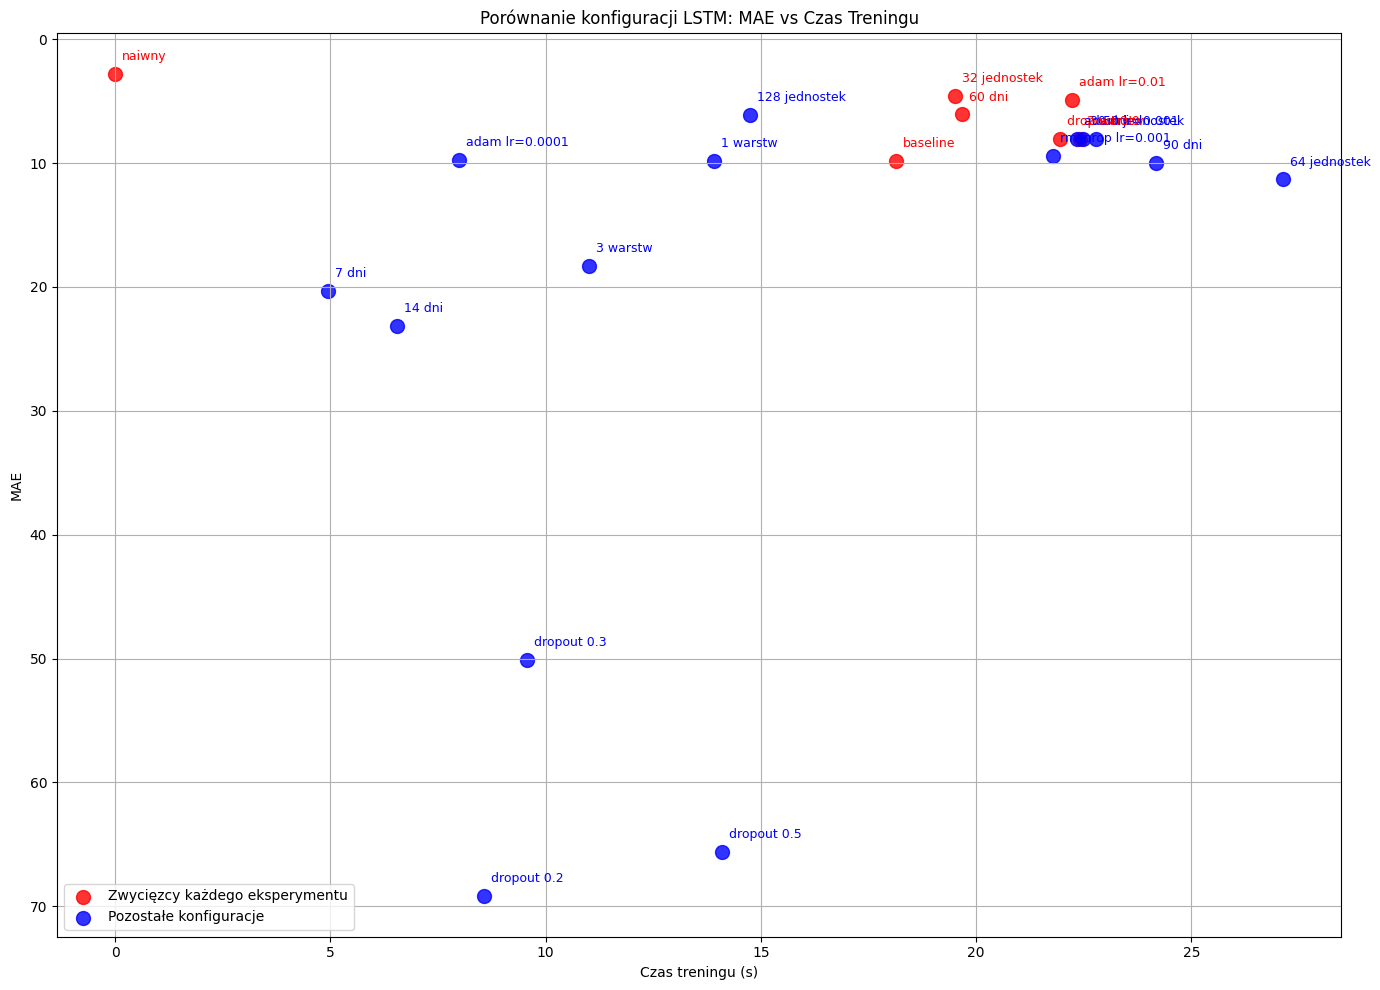

In [ ]:


# Identyfikacja zwycięzców w każdej kategorii
winner_naive_name = naive[0]['konfiguracja']
winner_baseline_name = baseline[0]['konfiguracja']
winner_depth_name = min(results_depth, key=lambda x: x['mae'])['konfiguracja']
winner_units_name = min(results_units, key=lambda x: x['mae'])['konfiguracja']
winner_lookback_name = min(results_lookback, key=lambda x: x['mae'])['konfiguracja']
winner_dropout_name = min(results_dropout, key=lambda x: x['mae'])['konfiguracja']
winner_opt_name = min(results_opt, key=lambda x: x['mae'])['konfiguracja']

all_winner_names = list(set([
    winner_naive_name,
    winner_baseline_name,
    winner_depth_name,
    winner_units_name,
    winner_lookback_name,
    winner_dropout_name,
    winner_opt_name
]))

# Dodanie kolumny z kolorem do DataFrame
df_results['color'] = df_results['konfiguracja'].apply(lambda x: 'red' if x in all_winner_names else 'blue')

display(df_results)

# wykres porównawczy: MAE vs Czas Treningu
plt.figure(figsize=(14, 10))

# Rysowanie zwycięzców
plt.scatter(df_results[df_results['color'] == 'red']['czas_treningu'],
            df_results[df_results['color'] == 'red']['mae'],
            c='red', s=100, alpha=0.8, label='Zwycięzcy każdego eksperymentu')

# Rysowanie pozostałych konfiguracji
plt.scatter(df_results[df_results['color'] == 'blue']['czas_treningu'],
            df_results[df_results['color'] == 'blue']['mae'],
            c='blue', s=100, alpha=0.8, label='Pozostałe konfiguracje')

plt.xlabel('Czas treningu (s)')
plt.ylabel('MAE')
plt.title('Porównanie konfiguracji LSTM: MAE vs Czas Treningu')

# Odwrócenie osi Y
plt.gca().invert_yaxis()

for i, row in df_results.iterrows():
    plt.annotate(row['konfiguracja'], (row['czas_treningu'], row['mae']),
                 textcoords="offset points", xytext=(5,10), ha='left', fontsize=9, rotation=0, color=row['color'])

plt.legend()
plt.grid(True)
plt.tight_layout()
plt.show()


Zestawienie wyników wskazuje, że najniższy błąd uzyskał model naiwny (MAE = 2.80), co oznacza, że w analizowanym szeregu prosta predykcja oparta na ostatniej obserwacji stanowi bardzo silny punkt odniesienia, trudny do przewyższenia przez rozważane konfiguracje LSTM. Wśród modeli LSTM najlepsze rezultaty osiągnięto dla architektury z 32 jednostkami (MAE = 4.60) oraz przy zastosowaniu optymalizatora Adam z lr = 0.01 (MAE = 4.91), natomiast zbyt krótkie okno czasowe (7–14 dni), nadmierna głębokość (3 warstwy) oraz regularizacja dropout (0.2–0.5) prowadziły do wyraźnego pogorszenia jakości predykcji. Jednocześnie czasy treningu nie wykazywały jednoznacznej zależności z błędem, co sugeruje, że wzrost kosztu obliczeniowego nie przekładał się automatycznie na poprawę trafności modelu.


## Wizualizacja predykcji najlepszego modelu
Na podstawie wyników eksperymentów jako najlepszą konfigurację wybrano model LSTM z 2 warstwami, 32 jednostkami, dropout = 0.0, oknem czasowym 60 dni oraz optymalizatorem Adam (learning rate = 0.01), ponieważ zestaw tych ustawień dawał najniższe wartości MAE w odpowiednich porównaniach.



/usr/local/lib/python3.12/dist-packages/keras/src/layers/rnn/rnn.py:199: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(**kwargs)


5/5 ━━━━━━━━━━━━━━━━━━━━ 0s 53ms/step
MAE najlepszego modelu: 7.4488
Czas treningu najlepszego modelu: 17.72 s


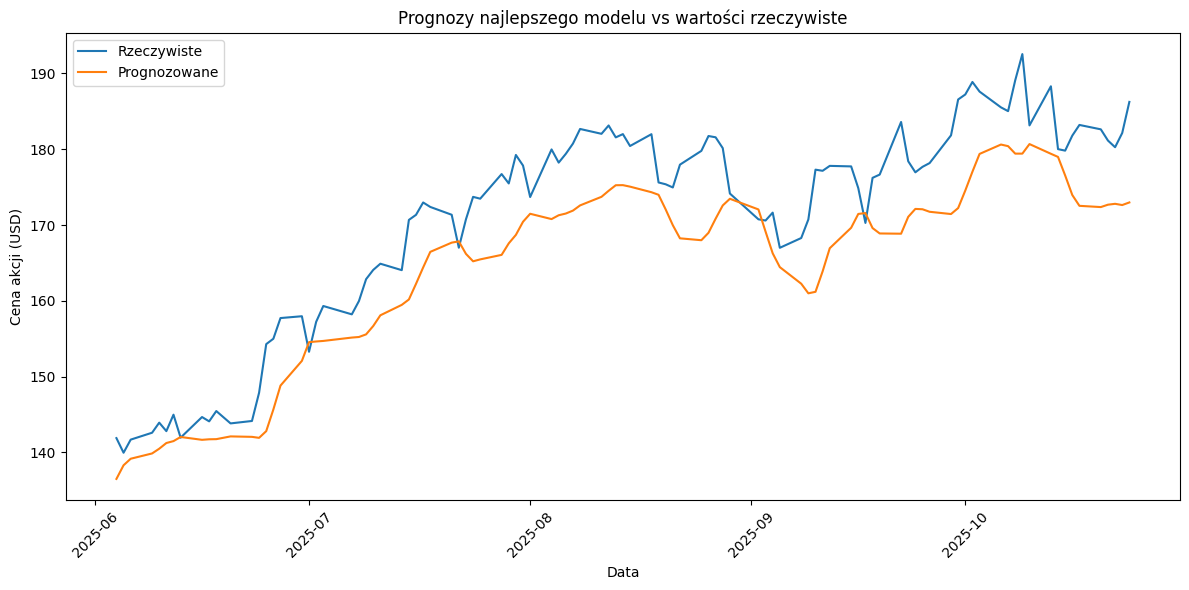

In [ ]:

n_steps_best = 60

X_all_best, y_all_best = create_sequences(scaled, n_steps_best)
train_size_best = int(len(X_all_best) * 0.7)
val_size_best = int(len(X_all_best) * 0.2)
X_train_best, y_train_best = X_all_best[:train_size_best], y_all_best[:train_size_best]
X_val_best, y_val_best = X_all_best[train_size_best:train_size_best + val_size_best], y_all_best[train_size_best:train_size_best + val_size_best]
X_test_best, y_test_best = X_all_best[train_size_best + val_size_best:], y_all_best[train_size_best + val_size_best:]
X_train_best = X_train_best.reshape((X_train_best.shape[0], X_train_best.shape[1], 1))
X_val_best = X_val_best.reshape((X_val_best.shape[0], X_val_best.shape[1], 1))
X_test_best = X_test_best.reshape((X_test_best.shape[0], X_test_best.shape[1], 1))
y_test_inv_best = scaler.inverse_transform(y_test_best).flatten()

best_model = build_lstm_model(n_layers=2, units=32, dropout=0.0, optimizer_name='adam', learning_rate=0.01)

start_time_best_model = time.time()
best_model.fit(X_train_best, y_train_best, epochs=30, batch_size=32, validation_data=(X_val_best, y_val_best), verbose=0,
              callbacks=[EarlyStopping(monitor='val_loss', patience=5, restore_best_weights=True)])
training_time_best_model = time.time() - start_time_best_model

best_pred = best_model.predict(X_test_best).flatten()
best_pred_inv = scaler.inverse_transform(best_pred.reshape(-1, 1)).flatten()

mae_best_model = mean_absolute_error(y_test_inv_best, best_pred_inv)

print(f"MAE najlepszego modelu: {mae_best_model:.4f}")
print(f"Czas treningu najlepszego modelu: {training_time_best_model:.2f} s")

plot_df = pd.DataFrame({
    'Rzeczywiste': y_test_inv_best[:100],
    'Prognozowane': best_pred_inv[:100]
}, index=prices.index[-len(y_test_inv_best):][:100])

# wizualizacja
plt.figure(figsize=(12, 6))
plt.plot(plot_df.index, plot_df['Rzeczywiste'], label='Rzeczywiste')
plt.plot(plot_df.index, plot_df['Prognozowane'], label='Prognozowane')
plt.xlabel('Data')
plt.ylabel('Cena akcji (USD)')
plt.title('Prognozy najlepszego modelu vs wartości rzeczywiste')
plt.legend()
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()


Po treningu modelu uzyskano MAE = 7.45 przy czasie uczenia 17.72 s, co oznacza, że końcowa jakość predykcji zależy nie tylko od doboru architektury i hiperparametrów, ale również od warunków startowych uczenia. W praktyce nawet przy tej samej konfiguracji różnice w inicjalizacji wag oraz w przebiegu optymalizacji mogą prowadzić do odmiennych minimów funkcji straty, a tym samym do zauważalnych wahań błędu na zbiorze testowym.


## Analiza błędów


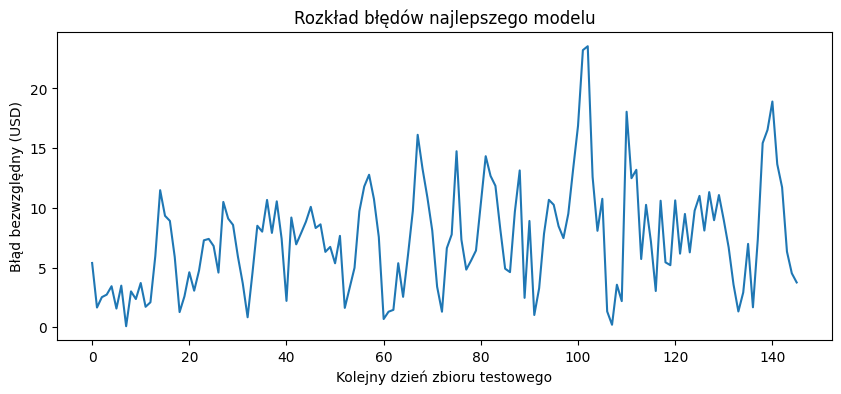

Średni błąd bezwzględny: 7.448846163815015
Maksymalny błąd bezwzględny: 23.532608032226562


In [ ]:

errors = np.abs(best_pred_inv - y_test_inv_best)

plt.figure(figsize=(10, 4))
plt.plot(errors)
plt.xlabel('Kolejny dzień zbioru testowego')
plt.ylabel('Błąd bezwzględny (USD)')
plt.title('Rozkład błędów najlepszego modelu')
plt.show()

print('Średni błąd bezwzględny:', np.mean(errors))
print('Maksymalny błąd bezwzględny:', np.max(errors))


##Ograniczenia i możliwe usprawnienia modelu

Ograniczeniem podejścia jest oparcie modelu wyłącznie na cenie zamknięcia (Close), co zawęża informację wejściową i utrudnia uchwycenie zmian wynikających z wolumenu, dziennej zmienności czy czynników zewnętrznych, a dodatkowo wyniki pozostają wrażliwe na inicjalizację i przebieg uczenia. Usprawnienia mogłyby obejmować rozszerzenie zbioru cech o pozostałe zmienne rynkowe (np. Open/High/Low/Volume) oraz proste wskaźniki techniczne, a także ocenę stabilności poprzez wielokrotne uruchomienia tej samej konfiguracji i raportowanie uśrednionych wyników zamiast pojedynczego pomiaru.

##Wnioski

Przeprowadzone eksperymenty wykazały, że jakość predykcji modeli LSTM istotnie zależy od doboru hiperparametrów, przy czym korzystne okazały się umiarkowana złożoność architektury (2 warstwy) oraz mniejsza liczba jednostek (32) i dłuższe okno czasowe (60 dni), natomiast zwiększanie głębokości do 3 warstw oraz stosowanie dropout prowadziło do wyraźnego pogorszenia wyników. Jednocześnie model naiwny osiągnął najniższy błąd, co wskazuje, że w analizowanym szeregu krótkoterminowa prognoza oparta na ostatniej obserwacji jest wyjątkowo trudnym do pobicia punktem odniesienia. W konsekwencji uzasadnienie przewagi LSTM wymagałoby wzbogacenia danych wejściowych oraz bardziej rygorystycznej oceny stabilności wyników (np. powtórzeń treningu i raportowania miar uśrednionych).